Here is our original dataset. It does not qualify as a tidy dataset for multiple reasons. Firstly, each variable is not in its own column-- for example, there are multiple columns with values from the 60s. Secondly, each observation does not form its own row-- there are currently many different observations in each row. In addition, some values are in the float category while others are integers, which would make it difficult for a computer to make calculations. However, this dataset does meet the criteria that every type of observational unit should form its own table, since the only observational unit we are dealing with is "Members".

In [3]:
import pandas as pd

#Import the dataset in a wide-frame format
df_moneyball = pd.read_csv("Data/mutant_moneyball.csv")

print("Original (Untidy) Moneyball DataFrame:")
print(df_moneyball)


Original (Untidy) Moneyball DataFrame:
                 Member  TotalValue60s_heritage  TotalValue70s_heritage  \
0     warrenWorthington                929056.0                154585.0   
1             hankMcCoy                929776.0                 20705.0   
2          scottSummers                933616.0                188635.0   
3            bobbyDrake                929776.0                154585.0   
4              jeanGrey                933616.0                179899.0   
5           alexSummers                 34519.0                144946.0   
6             lornaDane                 76279.0                144946.0   
7           ororoMunroe                     NaN                171050.0   
8            kurtWagner                     NaN                171050.0   
9          loganHowlett                     NaN                171050.0   
10        peterRasputin                     NaN                171050.0   
11          seanCassidy                 39200.0              

In order to tidy up this dataset, we must first melt the dataframe so that each observation forms its own row. To do this, we will use the pd.melt() function. After this step is done, there still be multiple variables per column (i.e. a decade and a source), but now we will no longer have to deal with superfluous columns. 

In [4]:
#Melt the dataframe so that each observation forms its own row
df_moneyball_melted = pd.melt(df_moneyball, id_vars = ['Member'], var_name = "Variable", value_name = "Value")

print("\nMelted Moneyball DataFrame:")
print(df_moneyball_melted)


Melted Moneyball DataFrame:
                Member                Variable     Value
0    warrenWorthington  TotalValue60s_heritage  929056.0
1            hankMcCoy  TotalValue60s_heritage  929776.0
2         scottSummers  TotalValue60s_heritage  933616.0
3           bobbyDrake  TotalValue60s_heritage  929776.0
4             jeanGrey  TotalValue60s_heritage  933616.0
..                 ...                     ...       ...
411         remyLeBeau   TotalValue90s_oStreet  $188.00 
412      jubilationLee   TotalValue90s_oStreet  $126.00 
413        lucasBishop   TotalValue90s_oStreet   $80.00 
414      betsyBraddock   TotalValue90s_oStreet  $109.00 
415      charlesXavier   TotalValue90s_oStreet  $125.00 

[416 rows x 3 columns]


Now, it is time to split the dataset into 2 new columns, with each column representing a variable. The two variables will be "Decade" and "Source", and we will use the str.split() function. In addition, we will have to get rid of the "variable" column using the .drop()  function, since this column has multiple variables and is no longer necessary. Lastly, I rearranged the order of the columns so that "value" would be last, since it is the primary column we would be looking at.

In [5]:
#Split the dataset into 2 new columns, with each column representing a variable
df_moneyball_melted[["Decade", "Source"]] = df_moneyball_melted["Variable"].str.split("_", expand=True)

#Get rid of the "Variable" column since it is no longer necessary
df_moneyball_melted = df_moneyball_melted.drop(columns=["Variable"])

#Rearrange the order of the columns so that "Value" comes last
df_moneyball_melted = df_moneyball_melted[["Member", "Decade", "Source", "Value"]]

print("\nMelted & Split Moneyball DataFrame:")
print(df_moneyball_melted)


Melted & Split Moneyball DataFrame:
                Member         Decade    Source     Value
0    warrenWorthington  TotalValue60s  heritage  929056.0
1            hankMcCoy  TotalValue60s  heritage  929776.0
2         scottSummers  TotalValue60s  heritage  933616.0
3           bobbyDrake  TotalValue60s  heritage  929776.0
4             jeanGrey  TotalValue60s  heritage  933616.0
..                 ...            ...       ...       ...
411         remyLeBeau  TotalValue90s   oStreet  $188.00 
412      jubilationLee  TotalValue90s   oStreet  $126.00 
413        lucasBishop  TotalValue90s   oStreet   $80.00 
414      betsyBraddock  TotalValue90s   oStreet  $109.00 
415      charlesXavier  TotalValue90s   oStreet  $125.00 

[416 rows x 4 columns]


Next, we need to clean up the strings that represent the columns titles, getting rid of "TotalValue" which is no longer necessary since the last column represents the values. We also must get rid of dollar signs that are on some of the values but not others, and make sure that all values are converted to floats so that the computer can perform calculations on all values at the same time.

In [6]:
#Clean up strings with unwanted information and convert all values into the same data type
df_moneyball_melted["Decade"] = df_moneyball_melted["Decade"].str.replace("TotalValue", "")
df_moneyball_melted["Value"] = (
    df_moneyball_melted["Value"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
    .astype(float))

print(df_moneyball_melted)

                Member Decade    Source     Value
0    warrenWorthington    60s  heritage  929056.0
1            hankMcCoy    60s  heritage  929776.0
2         scottSummers    60s  heritage  933616.0
3           bobbyDrake    60s  heritage  929776.0
4             jeanGrey    60s  heritage  933616.0
..                 ...    ...       ...       ...
411         remyLeBeau    90s   oStreet     188.0
412      jubilationLee    90s   oStreet     126.0
413        lucasBishop    90s   oStreet      80.0
414      betsyBraddock    90s   oStreet     109.0
415      charlesXavier    90s   oStreet     125.0

[416 rows x 4 columns]


Now we will make a bar plot visualization that shows the values of the comics across each decade.

<Axes: xlabel='Decade', ylabel='Value'>

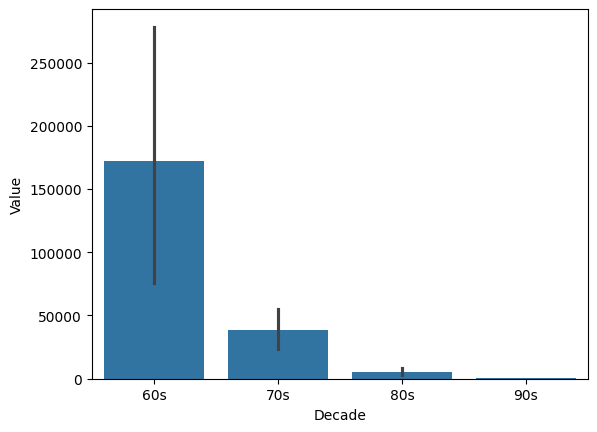

In [7]:
#Create visualizations that reflect the newly cleaned data

#First, import seaborn and matplotlib
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=df_moneyball_melted, x="Decade", y="Value")



Here, the decrease in value across decades shows the decrease in popularity of the X-men comics over time.

Next, we will make a bar plot visualization showing the value of comics sold with each character featured in them.

<Axes: xlabel='Value', ylabel='Member'>

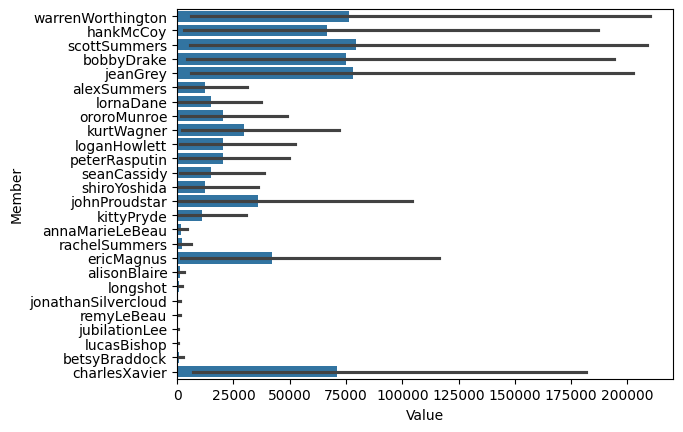

In [9]:
sns.barplot(data=df_moneyball_melted, x="Value", y="Member")

Here we can see each X-men member in terms of the value of the issues they appeared in. This could indicate the popularity of the character or the amount of issues they appeared in.

Finally, we will make a pivot table that shows the average values of comic sales across both decades and sources. The rows will represent decades and the columns will represent sources.

In [ ]:
#Make a pivot table to describe the mean value per decade for each source.

pivot_table = pd.pivot_table(df_moneyball_melted, values='Value',
                                    index='Decade', columns='Source', aggfunc='mean')

print(pivot_table)

Source          ebay       heritage       oStreet          wiz
Decade                                                        
60s     15697.700000  620830.900000  45678.500000  5204.800000
70s      3445.750000  143405.687500   6291.562500  1036.375000
80s       650.869565   19819.521739    873.434783   339.000000
90s        98.045455     943.727273    103.818182    67.931818


Here we can see that across all 4 decades, heritage seems to have sold the comics with the most value and wiz seems to have sold the comics with the least value.